## Problem Statement

<img src=https://www.matherhospital.org/wp-content/uploads/2017/09/brain-tumor-blog-photo.jpg width=500/>

A brain tumor is a mass or growth of abnormal cells in your brain.
Many different types of brain tumors exist. Some brain tumors are noncancerous (benign), and some brain tumors are cancerous (malignant). Brain tumors can begin in your brain (primary brain tumors), or cancer can begin in other parts of your body and spread to your brain as secondary (metastatic) brain tumors.
How quickly a brain tumor grows can vary greatly. The growth rate as well as the location of a brain tumor determines how it will affect the function of your nervous system.
Brain tumor treatment options depend on the type of brain tumor you have, as well as its size and location.

Our goal now is to design a deep learning system based on both vision transformers and Convolutional neural networks and compare both of them using different metrics.

In [1]:
!nvidia-smi

Thu Jan  8 04:07:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.172.08             Driver Version: 570.172.08     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Importing necessary libraries

In [2]:
!pip install visualkeras
import os
import warnings
import itertools
import cv2
import seaborn as sns
import pandas as pd
import numpy  as np
from PIL import Image
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter

import tensorflow as tf
import tensorflow_addons as tfa
import visualkeras
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.metrics import multilabel_confusion_matrix

from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.utils import plot_model
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from sklearn.model_selection   import train_test_split
from keras.preprocessing.image import ImageDataGenerator

warnings.filterwarnings('ignore')
%matplotlib inline

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 989.8/989.8 kB 17.5 MB/s eta 0:00:00a 0:00:01


In [3]:
tf.__version__

'2.6.4'

## Setting up general parameters

In [4]:
# General parameters
epochs = 15
pic_size = 240
np.random.seed(42)
tf.random.set_seed(42)

## Data Loading, Preperation and Visualization

In [5]:
folder_path = "/kaggle/input/augmented-images-dataset/Augmented_Img"
no_images = os.listdir(folder_path + '/aug_NO/')
yes_images = os.listdir(folder_path + '/aug_YES/')
dataset=[]
lab=[]

for image_name in no_images:
    image=cv2.imread(folder_path + '/aug_NO/' + image_name)
    image=Image.fromarray(image,'RGB')
    image=image.resize((240,240))
    dataset.append(np.array(image))
    lab.append(0)
    
for image_name in yes_images:
    image=cv2.imread(folder_path + '/aug_YES/' + image_name)
    image=Image.fromarray(image,'RGB')
    image=image.resize((240,240))
    dataset.append(np.array(image))
    lab.append(1)

In [6]:
dataset = np.array(dataset)
lab = np.array(lab)
print(dataset.shape, lab.shape)

(8992, 240, 240, 3) (8992,)


In [7]:
x_train, x_test, y_train, y_test = train_test_split(dataset, lab, test_size=0.2, shuffle=True, random_state=42)

In [8]:
def plot_state(state):
    plt.figure(figsize= (12,12))
    for i in range(1, 10, 1):
        plt.subplot(3,3,i)
        img = load_img(folder_path + "/" + state + "/" + os.listdir(folder_path + "/" + state)[i], target_size=(pic_size, pic_size))
        plt.imshow(img)   
    plt.show()

In [9]:
#plot_state('yes')

In [10]:
#plot_state("/kaggle/input/augmented-images-dataset/Augmented_Img/aug_NO/No12.jpg")

## Modeling using CNN

In [11]:
model = tf.keras.Sequential([
    
    tf.keras.layers.Conv2D(filters=32,kernel_size=(3,3),strides=(2,2), activation="relu", padding="valid",input_shape=(pic_size,pic_size,3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(filters=32,kernel_size=(3,3),strides=(2,2), activation="relu", padding="valid"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=64, activation='relu', 
                          kernel_regularizer=regularizers.L1L2(l1=1e-3, l2=1e-3), 
                          bias_regularizer=regularizers.L2(1e-2),
                          activity_regularizer=regularizers.L2(1e-3)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=1, activation='sigmoid'),
])

In [12]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 119, 119, 32)      896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 59, 59, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 29, 29, 32)        9248      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 14, 14, 32)        0         
_________________________________________________________________
flatten (Flatten)            (None, 6272)              0         
_________________________________________________________________
dense (Dense)                (None, 64)                401472    
_________________________________________________________________
dropout (Dropout)            (None, 64)                0

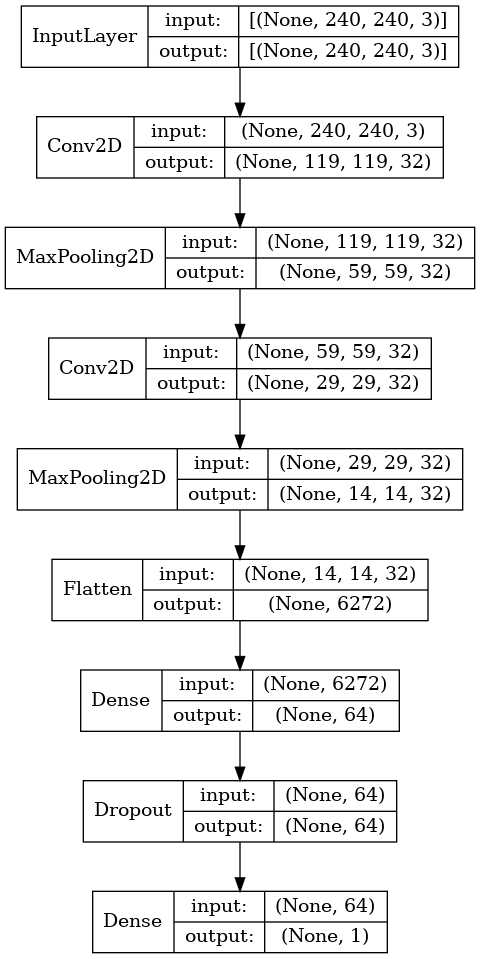

In [13]:
plot_model(model, show_shapes=True, show_layer_names=False)

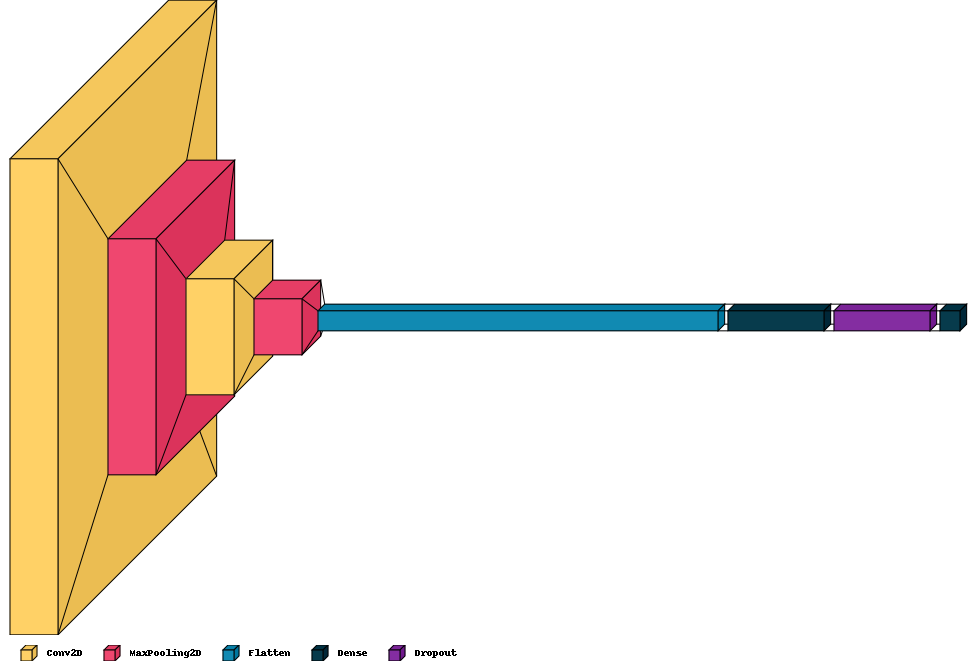

In [14]:
visualkeras.layered_view(model, legend=True)

In [15]:
class_weights = class_weight.compute_class_weight(class_weight = "balanced", classes= np.unique(y_train), y= y_train)
class_weights = dict(zip(np.unique(y_train), class_weights))
class_weights

{0: 1.0001390433815351, 1: 0.9998609952738393}

In [16]:
history = model.fit(x_train,y_train,epochs = 100, class_weight=class_weights, validation_data=(x_test, y_test),verbose=1)

Epoch 1/100
225/225 [==============================] - 12s 15ms/step - loss: 4.3583 - accuracy: 0.5628 - val_loss: 2.7870 - val_accuracy: 0.8027
Epoch 2/100
225/225 [==============================] - 2s 11ms/step - loss: 2.3002 - accuracy: 0.7418 - val_loss: 1.8641 - val_accuracy: 0.8188
Epoch 3/100
225/225 [==============================] - 2s 11ms/step - loss: 1.6455 - accuracy: 0.7883 - val_loss: 1.3828 - val_accuracy: 0.8482
Epoch 4/100
225/225 [==============================] - 2s 11ms/step - loss: 1.2873 - accuracy: 0.8059 - val_loss: 1.2713 - val_accuracy: 0.7871
Epoch 5/100
225/225 [==============================] - 2s 11ms/step - loss: 1.1405 - accuracy: 0.7999 - val_loss: 0.9686 - val_accuracy: 0.8660
Epoch 6/100
225/225 [==============================] - 2s 11ms/step - loss: 0.9223 - accuracy: 0.8396 - val_loss: 0.8664 - val_accuracy: 0.8705
Epoch 7/100
225/225 [==============================] - 2s 11ms/step - loss: 0.8177 - accuracy: 0.8544 - val_loss: 0.8323 - val_accuracy

## CNN model Evaluation

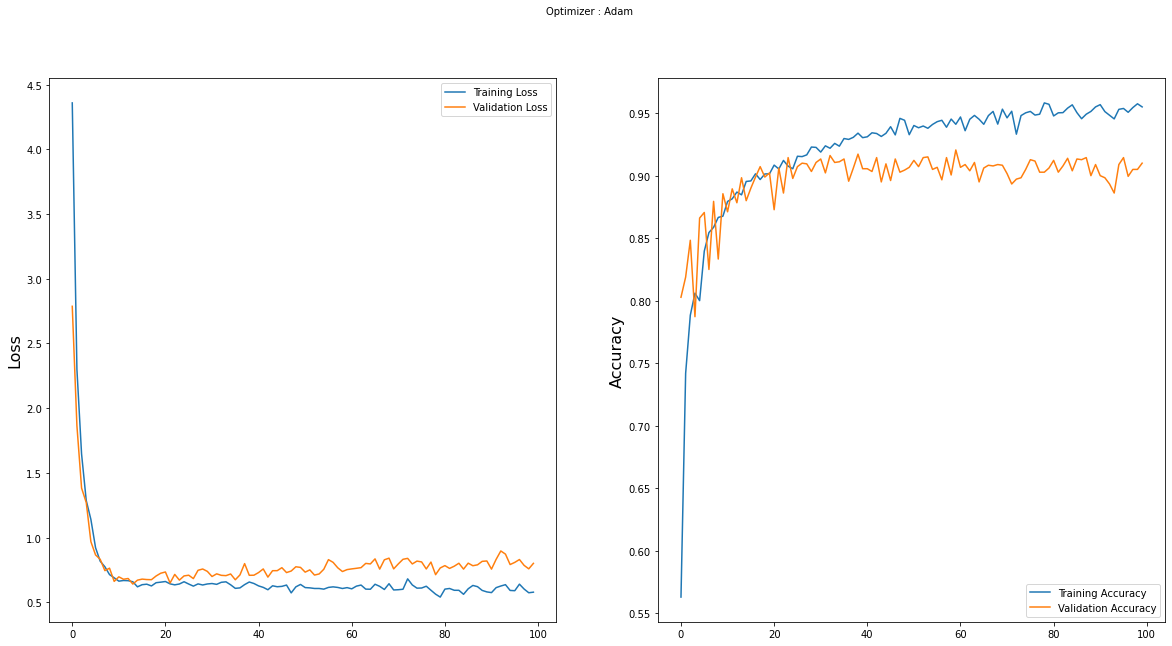

In [17]:
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : Adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

In [18]:
results = model.evaluate(x_test, y_test)
print('The current model achieved an accuracy of {}%!'.format(round(results[1]*100,2)))

57/57 [==============================] - 0s 5ms/step - loss: 0.8012 - accuracy: 0.9099
The current model achieved an accuracy of 90.99%!


In [19]:
# compute predictions
predictions = model.predict(x_test)
y_pred = []
for i in predictions:
    if i >= 0.5:
        y_pred.append(1)
    else:
        y_pred.append(0)

In [20]:
def plot_confusion_matrix(cm, classes, title='Confusion matrix', cmap=plt.cm.Blues):
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(10,10))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

<Figure size 216x216 with 0 Axes>

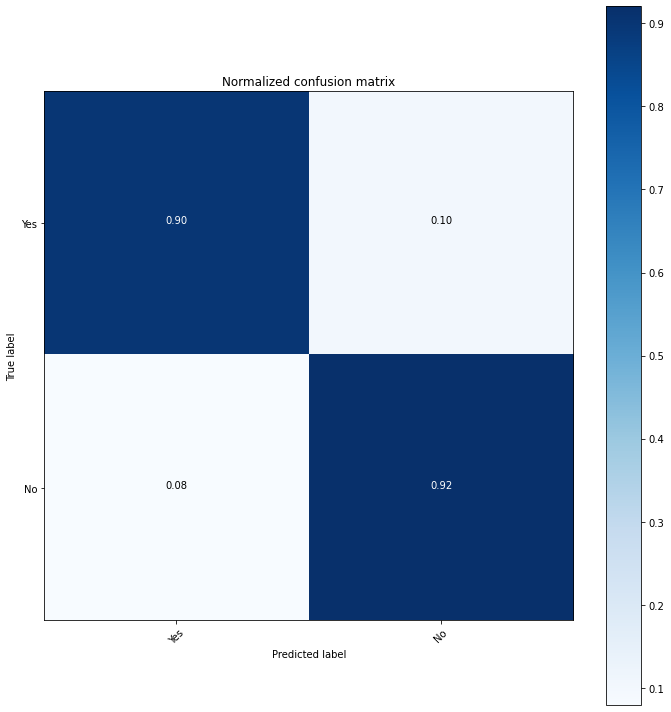

In [21]:
# compute confusion matrix
cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)
# plot normalized confusion matrix
plt.figure(figsize=(3, 3))
plot_confusion_matrix(cnf_matrix, classes=["Yes", "No"], title='Normalized confusion matrix')
plt.show()

## Modeling using Vision Transformers(ViT)

In [22]:
learning_rate = 0.001
weight_decay = 0.0001
batch_size = 256
num_epochs = 100
image_size = 240  # We'll resize input images to this size
patch_size = 20  # Size of the patches to be extract from the input images
num_patches = (image_size // patch_size) ** 2
projection_dim = 64
num_heads = 4
transformer_units = [
    projection_dim * 2,
    projection_dim,
]  # Size of the transformer layers
transformer_layers = 8
mlp_head_units = [2048, 1024]  # Size of the dense layers of the final classifier

## Data augmentation

In [23]:
# Replace 'your-dataset-name' with the actual path from the Kaggle Data tab
input_folder = '/kaggle/input/brain-tumor-detection/no'
output_folder = '/kaggle/working/rotated_imagesNO'

# The rest of your script
import os
from PIL import Image
import random

def rotate_and_save_images(input_folder, output_folder, rotation_range=(-15, 15)):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
        print(f"Created output directory: {output_folder}")
    
    image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')
    processed_count = 0
    
    # Loop through each file in the input folder
    for filename in os.listdir(input_folder):
        if filename.lower().endswith(image_extensions):
            file_path = os.path.join(input_folder, filename)
            
            try:
                with Image.open(file_path) as img:
                    angle = random.uniform(rotation_range[0], rotation_range[1])
                    rotated_img = img.rotate(angle, resample=Image.BICUBIC, expand=True)
                    
                    base, ext = os.path.splitext(filename)
                    new_filename = f"{base}_rot{int(angle)}{ext}"
                    new_file_path = os.path.join(output_folder, new_filename)
                    
                    rotated_img.save(new_file_path)
                    processed_count += 1
                    print(f"Successfully rotated and saved: {new_filename}")

            except Exception as e:
                print(f"Error processing {filename}: {e}")

    print("-" * 50)
    print(f"Operation complete. Processed {processed_count} images.")

rotate_and_save_images(input_folder, output_folder)

Created output directory: /kaggle/working/rotated_imagesNO
Successfully rotated and saved: no26_rot-1.jpg
Successfully rotated and saved: no979_rot10.jpg
Successfully rotated and saved: no598_rot-3.jpg
Successfully rotated and saved: no141_rot14.jpg
Successfully rotated and saved: no715_rot14.jpg
Successfully rotated and saved: no122_rot6.jpg
Successfully rotated and saved: no457_rot1.jpg
Successfully rotated and saved: no895_rot11.jpg
Successfully rotated and saved: no446_rot-14.jpg
Successfully rotated and saved: no395_rot5.jpg
Successfully rotated and saved: no89_rot10.jpg
Successfully rotated and saved: no632_rot13.jpg
Successfully rotated and saved: no420_rot-11.jpg
Successfully rotated and saved: no634_rot3.jpg
Successfully rotated and saved: no1142_rot-9.jpg
Successfully rotated and saved: no473_rot-8.jpg
Successfully rotated and saved: no1244_rot11.jpg
Successfully rotated and saved: no474_rot13.jpg
Successfully rotated and saved: no706_rot-12.jpg
Successfully rotated and saved

In [24]:
# Replace 'your-dataset-name' with the actual path from the Kaggle Data tab
input_folder = '/kaggle/input/brain-tumor-detection/yes'
output_folder = '/kaggle/working/rotated_images'

# The rest of your script
import os
from PIL import Image
import random

def rotate_and_save_images(input_folder, output_folder, rotation_range=(-15, 15)):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
        print(f"Created output directory: {output_folder}")
    
    image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')
    processed_count = 0
    
    # Loop through each file in the input folder
    for filename in os.listdir(input_folder):
        if filename.lower().endswith(image_extensions):
            file_path = os.path.join(input_folder, filename)
            
            try:
                with Image.open(file_path) as img:
                    angle = random.uniform(rotation_range[0], rotation_range[1])
                    rotated_img = img.rotate(angle, resample=Image.BICUBIC, expand=True)
                    
                    base, ext = os.path.splitext(filename)
                    new_filename = f"{base}_rot{int(angle)}{ext}"
                    new_file_path = os.path.join(output_folder, new_filename)
                    
                    rotated_img.save(new_file_path)
                    processed_count += 1
                    print(f"Successfully rotated and saved: {new_filename}")

            except Exception as e:
                print(f"Error processing {filename}: {e}")

    print("-" * 50)
    print(f"Operation complete. Processed {processed_count} images.")

rotate_and_save_images(input_folder, output_folder)

Created output directory: /kaggle/working/rotated_images
Successfully rotated and saved: y925_rot-4.jpg
Successfully rotated and saved: y424_rot-4.jpg
Successfully rotated and saved: y708_rot-5.jpg
Successfully rotated and saved: y115_rot-12.jpg
Successfully rotated and saved: y504_rot13.jpg
Successfully rotated and saved: y1206_rot-3.jpg
Successfully rotated and saved: y192_rot-13.jpg
Successfully rotated and saved: y217_rot0.jpg
Successfully rotated and saved: y937_rot-13.jpg
Successfully rotated and saved: y162_rot14.jpg
Successfully rotated and saved: y9_rot-8.jpg
Successfully rotated and saved: y511_rot13.jpg
Successfully rotated and saved: y717_rot-8.jpg
Successfully rotated and saved: y635_rot9.jpg
Successfully rotated and saved: y769_rot11.jpg
Successfully rotated and saved: y1348_rot-13.jpg
Successfully rotated and saved: y134_rot1.jpg
Successfully rotated and saved: y987_rot-3.jpg
Successfully rotated and saved: y1245_rot11.jpg
Successfully rotated and saved: y724_rot6.jpg
Su

In [25]:
pip install Pillow

Note: you may need to restart the kernel to use updated packages.


In [26]:
import os
from PIL import Image

def flip_and_save_images(input_folder, output_folder):
    """
    Performs a horizontal flip on all images in a folder and saves them.
    
    Args:
        input_folder (str): Path to the folder containing the original images.
        output_folder (str): Path to the folder where flipped images will be saved.
    """
    # Create the output directory if it doesn't exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
        print(f"Created output directory: {output_folder}")

    # Supported image extensions
    image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')
    
    # Counter for the new image series
    series_number = 1
    
    # Loop through each file in the input folder
    for filename in os.listdir(input_folder):
        file_path = os.path.join(input_folder, filename)
        
        # Check if the file is a supported image and not a directory
        if os.path.isfile(file_path) and filename.lower().endswith(image_extensions):
            try:
                # Open the image
                with Image.open(file_path) as img:
                    # Perform the horizontal flip
                    flipped_img = img.transpose(Image.FLIP_LEFT_RIGHT)
                    
                    # Create the new filename with the requested series format
                    new_filename = f"hf{series_number:02d}{os.path.splitext(filename)[1]}"
                    new_file_path = os.path.join(output_folder, new_filename)
                    
                    # Save the flipped image
                    flipped_img.save(new_file_path)
                    
                    print(f"Flipped and saved: {filename} -> {new_filename}")
                    series_number += 1
            
            except Exception as e:
                print(f"Error processing {filename}: {e}")

    print("-" * 50)
    print(f"Operation complete. Processed {series_number - 1} images.")

# --- How to use the function ---
if __name__ == "__main__":
    # --- CHANGE THESE PATHS TO YOUR FOLDER LOCATIONS ---
    input_folder = '/kaggle/input/brain-tumor-detection/yes'
    output_folder = '/kaggle/working/flipped_images_YES'
    
    flip_and_save_images(input_folder, output_folder)

Created output directory: /kaggle/working/flipped_images_YES
Flipped and saved: y925.jpg -> hf01.jpg
Flipped and saved: y424.jpg -> hf02.jpg
Flipped and saved: y708.jpg -> hf03.jpg
Flipped and saved: y115.jpg -> hf04.jpg
Flipped and saved: y504.jpg -> hf05.jpg
Flipped and saved: y1206.jpg -> hf06.jpg
Flipped and saved: y192.jpg -> hf07.jpg
Flipped and saved: y217.jpg -> hf08.jpg
Flipped and saved: y937.jpg -> hf09.jpg
Flipped and saved: y162.jpg -> hf10.jpg
Flipped and saved: y9.jpg -> hf11.jpg
Flipped and saved: y511.jpg -> hf12.jpg
Flipped and saved: y717.jpg -> hf13.jpg
Flipped and saved: y635.jpg -> hf14.jpg
Flipped and saved: y769.jpg -> hf15.jpg
Flipped and saved: y1348.jpg -> hf16.jpg
Flipped and saved: y134.jpg -> hf17.jpg
Flipped and saved: y987.jpg -> hf18.jpg
Flipped and saved: y1245.jpg -> hf19.jpg
Flipped and saved: y724.jpg -> hf20.jpg
Flipped and saved: y1496.jpg -> hf21.jpg
Flipped and saved: y1446.jpg -> hf22.jpg
Flipped and saved: y840.jpg -> hf23.jpg
Flipped and save

In [27]:
import os
from PIL import Image

def flip_and_save_images(input_folder, output_folder):
    """
    Performs a horizontal flip on all images in a folder and saves them.
    
    Args:
        input_folder (str): Path to the folder containing the original images.
        output_folder (str): Path to the folder where flipped images will be saved.
    """
    # Create the output directory if it doesn't exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
        print(f"Created output directory: {output_folder}")

    # Supported image extensions
    image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')
    
    # Counter for the new image series
    series_number = 1
    
    # Loop through each file in the input folder
    for filename in os.listdir(input_folder):
        file_path = os.path.join(input_folder, filename)
        
        # Check if the file is a supported image and not a directory
        if os.path.isfile(file_path) and filename.lower().endswith(image_extensions):
            try:
                # Open the image
                with Image.open(file_path) as img:
                    # Perform the horizontal flip
                    flipped_img = img.transpose(Image.FLIP_LEFT_RIGHT)
                    
                    # Create the new filename with the requested series format
                    # The change is here: "hfno"
                    new_filename = f"hfno{series_number:02d}{os.path.splitext(filename)[1]}"
                    new_file_path = os.path.join(output_folder, new_filename)
                    
                    # Save the flipped image
                    flipped_img.save(new_file_path)
                    
                    print(f"Flipped and saved: {filename} -> {new_filename}")
                    series_number += 1
            
            except Exception as e:
                print(f"Error processing {filename}: {e}")

    print("-" * 50)
    print(f"Operation complete. Processed {series_number - 1} images.")

# --- How to use the function ---
if __name__ == "__main__":
    # --- CHANGE THESE PATHS TO YOUR FOLDER LOCATIONS ---
    input_folder = '/kaggle/input/brain-tumor-detection/no'
    output_folder = '/kaggle/working/flipped_images_NO'
    
    flip_and_save_images(input_folder, output_folder)

Created output directory: /kaggle/working/flipped_images_NO
Flipped and saved: no26.jpg -> hfno01.jpg
Flipped and saved: no979.jpg -> hfno02.jpg
Flipped and saved: no598.jpg -> hfno03.jpg
Flipped and saved: no141.jpg -> hfno04.jpg
Flipped and saved: no715.jpg -> hfno05.jpg
Flipped and saved: no122.jpg -> hfno06.jpg
Flipped and saved: no457.jpg -> hfno07.jpg
Flipped and saved: no895.jpg -> hfno08.jpg
Flipped and saved: no446.jpg -> hfno09.jpg
Flipped and saved: no395.jpg -> hfno10.jpg
Flipped and saved: no89.jpg -> hfno11.jpg
Flipped and saved: no632.jpg -> hfno12.jpg
Flipped and saved: no420.jpg -> hfno13.jpg
Flipped and saved: no634.jpg -> hfno14.jpg
Flipped and saved: no1142.jpg -> hfno15.jpg
Flipped and saved: no473.jpg -> hfno16.jpg
Flipped and saved: no1244.jpg -> hfno17.jpg
Flipped and saved: no474.jpg -> hfno18.jpg
Flipped and saved: no706.jpg -> hfno19.jpg
Flipped and saved: no161.jpg -> hfno20.jpg
Flipped and saved: no142.jpg -> hfno21.jpg
Flipped and saved: no849.jpg -> hfno2

In [28]:
import os
import shutil

def create_downloadable_zip(folder_name):
    """
    Compresses a folder in the Kaggle working directory into a .zip file
    for easy download.
    """
    source_folder_path = os.path.join('/kaggle/working', folder_name)
    output_zip_path = os.path.join('/kaggle/working', folder_name)

    print(f"Checking for folder at: {source_folder_path}")

    if os.path.exists(source_folder_path) and os.path.isdir(source_folder_path):
        try:
            shutil.make_archive(output_zip_path, 'zip', source_folder_path)
            print(f"\nSuccess! The folder '{folder_name}' has been zipped. You can now download it.")
        except Exception as e:
            print(f"\nAn error occurred during compression: {e}")
    else:
        print(f"\nError: The folder '{folder_name}' was not found. Please check the folder name and try again.")
        print("Available folders are:", os.listdir('/kaggle/working'))


# --- MAIN EXECUTION ---
# You need to use a folder name that actually exists in your Kaggle working directory
folder_to_zip = 'rotated_imagesNO'

create_downloadable_zip(folder_to_zip)

Checking for folder at: /kaggle/working/rotated_imagesNO

Success! The folder 'rotated_imagesNO' has been zipped. You can now download it.


In [29]:
import os
import shutil

def create_downloadable_zip(folder_name):
    """
    Compresses a folder in the Kaggle working directory into a .zip file
    for easy download.
    """
    source_folder_path = os.path.join('/kaggle/working', folder_name)
    output_zip_path = os.path.join('/kaggle/working', folder_name)

    print(f"Checking for folder at: {source_folder_path}")

    if os.path.exists(source_folder_path) and os.path.isdir(source_folder_path):
        try:
            shutil.make_archive(output_zip_path, 'zip', source_folder_path)
            print(f"\nSuccess! The folder '{folder_name}' has been zipped. You can now download it.")
        except Exception as e:
            print(f"\nAn error occurred during compression: {e}")
    else:
        print(f"\nError: The folder '{folder_name}' was not found. Please check the folder name and try again.")
        print("Available folders are:", os.listdir('/kaggle/working'))


# --- MAIN EXECUTION ---
# You need to use a folder name that actually exists in your Kaggle working directory
folder_to_zip = 'rotated_images'

create_downloadable_zip(folder_to_zip)

Checking for folder at: /kaggle/working/rotated_images

Success! The folder 'rotated_images' has been zipped. You can now download it.


In [30]:
import os
import shutil

def create_downloadable_zip(folder_name):
    """
    Compresses a folder in the Kaggle working directory into a .zip file
    for easy download.
    """
    source_folder_path = os.path.join('/kaggle/working', folder_name)
    output_zip_path = os.path.join('/kaggle/working', folder_name)

    print(f"Checking for folder at: {source_folder_path}")

    if os.path.exists(source_folder_path) and os.path.isdir(source_folder_path):
        try:
            shutil.make_archive(output_zip_path, 'zip', source_folder_path)
            print(f"\nSuccess! The folder '{folder_name}' has been zipped. You can now download it.")
        except Exception as e:
            print(f"\nAn error occurred during compression: {e}")
    else:
        print(f"\nError: The folder '{folder_name}' was not found. Please check the folder name and try again.")
        print("Available folders are:", os.listdir('/kaggle/working'))


# --- MAIN EXECUTION ---
# You need to use a folder name that actually exists in your Kaggle working directory
folder_to_zip = 'flipped_images_NO'

create_downloadable_zip(folder_to_zip)

Checking for folder at: /kaggle/working/flipped_images_NO

Success! The folder 'flipped_images_NO' has been zipped. You can now download it.


In [31]:
import os
import shutil

def create_downloadable_zip(folder_name):
    """
    Compresses a folder in the Kaggle working directory into a .zip file
    for easy download.
    """
    source_folder_path = os.path.join('/kaggle/working', folder_name)
    output_zip_path = os.path.join('/kaggle/working', folder_name)

    print(f"Checking for folder at: {source_folder_path}")

    if os.path.exists(source_folder_path) and os.path.isdir(source_folder_path):
        try:
            shutil.make_archive(output_zip_path, 'zip', source_folder_path)
            print(f"\nSuccess! The folder '{folder_name}' has been zipped. You can now download it.")
        except Exception as e:
            print(f"\nAn error occurred during compression: {e}")
    else:
        print(f"\nError: The folder '{folder_name}' was not found. Please check the folder name and try again.")
        print("Available folders are:", os.listdir('/kaggle/working'))


# --- MAIN EXECUTION ---
# You need to use a folder name that actually exists in your Kaggle working directory
folder_to_zip = 'flipped_images_YES'

create_downloadable_zip(folder_to_zip)

Checking for folder at: /kaggle/working/flipped_images_YES

Success! The folder 'flipped_images_YES' has been zipped. You can now download it.


In [32]:
data_augmentation = tf.keras.Sequential(
    [
        layers.Normalization(),
        layers.Resizing(image_size, image_size),
        #layers.RandomFlip("horizontal"),
        #layers.RandomRotation(factor=0.02),
        #layers.RandomZoom(height_factor=0.2, width_factor=0.2),
    ],
    name="data_augmentation",
)
# Compute the mean and the variance of the training data for normalization.
data_augmentation.layers[0].adapt(x_train)

## Multi-layer perceptron

In [33]:
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

## Implement patch creation as a layer

In [34]:
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super(Patches, self).__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

Image size: 240 X 240
Patch size: 20 X 20
Patches per image: 144
Elements per patch: 1200


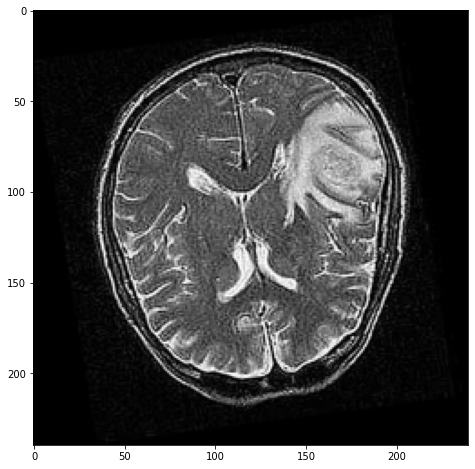

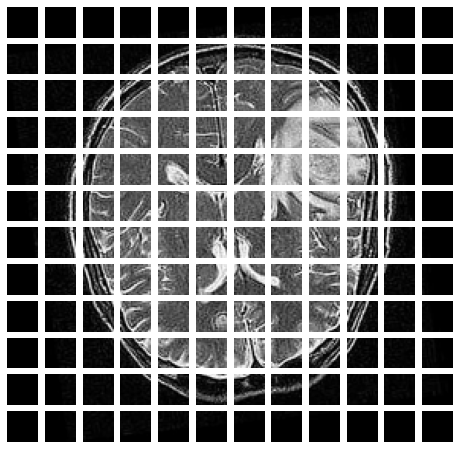

In [35]:
plt.figure(figsize=(8, 8))
image = x_train[np.random.choice(range(x_train.shape[0]))]
plt.imshow(image.astype("uint8"))

resized_image = tf.image.resize(
    tf.convert_to_tensor([image]), size=(image_size, image_size)
)
patches = Patches(patch_size)(resized_image)
print(f"Image size: {image_size} X {image_size}")
print(f"Patch size: {patch_size} X {patch_size}")
print(f"Patches per image: {patches.shape[1]}")
print(f"Elements per patch: {patches.shape[-1]}")

n = int(np.sqrt(patches.shape[1]))
plt.figure(figsize=(8, 8))
for i, patch in enumerate(patches[0]):
    ax = plt.subplot(n, n, i + 1)
    patch_img = tf.reshape(patch, (patch_size, patch_size, 3))
    plt.imshow(patch_img.numpy().astype("uint8"))
    plt.axis("off")


## Creating the patch encoder
The PatchEncoder layer will linearly transform a patch by projecting it into a vector of size projection_dim. In addition, it adds a learnable position embedding to the projected vector.

In [36]:
class PatchEncoder(tf.keras.layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super(PatchEncoder, self).__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

## Building the ViT

The ViT model consists of multiple Transformer blocks, which use the layers.MultiHeadAttention layer as a self-attention mechanism applied to the sequence of patches. The Transformer blocks produce a [batch_size, num_patches, projection_dim] tensor, which is processed via an classifier head with softmax to produce the final class probabilities output.

Unlike the technique described in the paper, which prepends a learnable embedding to the sequence of encoded patches to serve as the image representation, all the outputs of the final Transformer block are reshaped with layers.Flatten() and used as the image representation input to the classifier head. Note that the layers.GlobalAveragePooling1D layer could also be used instead to aggregate the outputs of the Transformer block, especially when the number of patches and the projection dimensions are large.

In [37]:
def create_vit_classifier():
    inputs = layers.Input(shape=(240, 240, 3))
    # Augment data.
    augmented = data_augmentation(inputs)
    # Create patches.
    patches = Patches(patch_size)(augmented)
    # Encode patches.
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    # Create multiple layers of the Transformer block.
    for _ in range(transformer_layers):
        # Layer normalization 1.
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        # Skip connection 1.
        x2 = layers.Add()([attention_output, encoded_patches])
        # Layer normalization 2.
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP.
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        # Skip connection 2.
        encoded_patches = layers.Add()([x3, x2])

    # Create a [batch_size, projection_dim] tensor.
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)
    # Add MLP.
    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.5)
    # Classify outputs.
    logits = layers.Dense(2)(features)
    # Create the Keras model.
    model = tf.keras.Model(inputs=inputs, outputs=logits)
    return model


In [38]:
def run_experiment(model):
    optimizer = tfa.optimizers.AdamW(
        learning_rate=learning_rate, weight_decay=weight_decay
    )

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[
            tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
            tf.keras.metrics.SparseTopKCategoricalAccuracy(5, name="top-5-accuracy"),
        ],
    )

    checkpoint_filepath = "/tmp/checkpoint"
    checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
        checkpoint_filepath,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
    )

    history = model.fit(
        x=x_train,
        y=y_train,
        batch_size=batch_size,
        epochs=num_epochs,
        validation_data=(x_test, y_test),
        callbacks=[checkpoint_callback],
    )

    model.load_weights(checkpoint_filepath)
    _, accuracy, top_5_accuracy = model.evaluate(x_test, y_test)
    print(f"Test accuracy: {round(accuracy * 100, 2)}%")
    print(f"Test top 5 accuracy: {round(top_5_accuracy * 100, 2)}%")

    return history

In [39]:
vit_classifier = create_vit_classifier()
vit_history = run_experiment(vit_classifier)

Epoch 1/100
29/29 [==============================] - 23s 480ms/step - loss: 2.0259 - accuracy: 0.6057 - top-5-accuracy: 1.0000 - val_loss: 0.5778 - val_accuracy: 0.6715 - val_top-5-accuracy: 1.0000
Epoch 2/100
29/29 [==============================] - 13s 434ms/step - loss: 0.6005 - accuracy: 0.7019 - top-5-accuracy: 1.0000 - val_loss: 0.5155 - val_accuracy: 0.7204 - val_top-5-accuracy: 1.0000
Epoch 3/100
29/29 [==============================] - 13s 446ms/step - loss: 0.5247 - accuracy: 0.7436 - top-5-accuracy: 1.0000 - val_loss: 0.4636 - val_accuracy: 0.7910 - val_top-5-accuracy: 1.0000
Epoch 4/100
29/29 [==============================] - 12s 432ms/step - loss: 0.4567 - accuracy: 0.7820 - top-5-accuracy: 1.0000 - val_loss: 0.3903 - val_accuracy: 0.8355 - val_top-5-accuracy: 1.0000
Epoch 5/100
29/29 [==============================] - 12s 423ms/step - loss: 0.3994 - accuracy: 0.8180 - top-5-accuracy: 1.0000 - val_loss: 0.3514 - val_accuracy: 0.8527 - val_top-5-accuracy: 1.0000
Epoch 6/10

## Notes about the ViT performance

The state of the art results reported in the paper are achieved by pre-training the ViT model using the JFT-300M dataset, then fine-tuning it on the target dataset. To improve the model quality without pre-training, you can try to train the model for more epochs, use a larger number of Transformer layers, resize the input images, change the patch size, or increase the projection dimensions. Besides, as mentioned in the paper, the quality of the model is affected not only by architecture choices, but also by parameters such as the learning rate schedule, optimizer, weight decay, etc. In practice, it's recommended to fine-tune a ViT model that was pre-trained using a large, high-resolution dataset.

## ViT model Evaluation

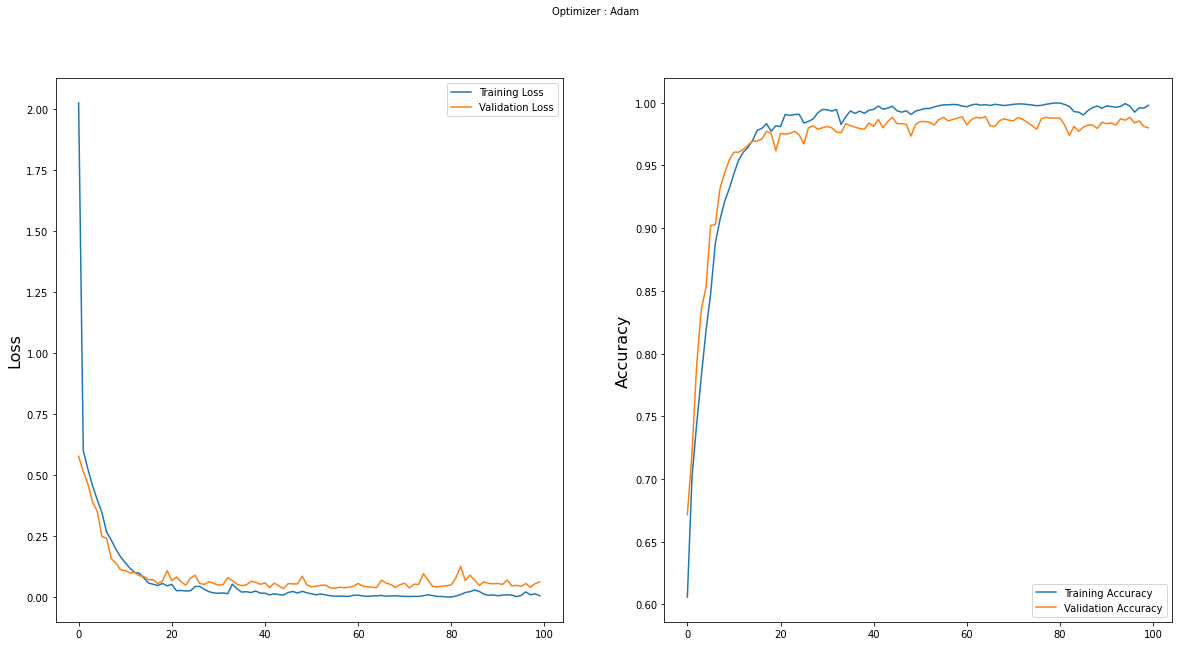

In [40]:
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : Adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(vit_history.history['loss'], label='Training Loss')
plt.plot(vit_history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(vit_history.history['accuracy'], label='Training Accuracy')
plt.plot(vit_history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

In [41]:
# compute predictions
vit_predictions = vit_classifier.predict(x_test)
vit_y_pred = [np.argmax(probas) for probas in vit_predictions]

<Figure size 648x648 with 0 Axes>

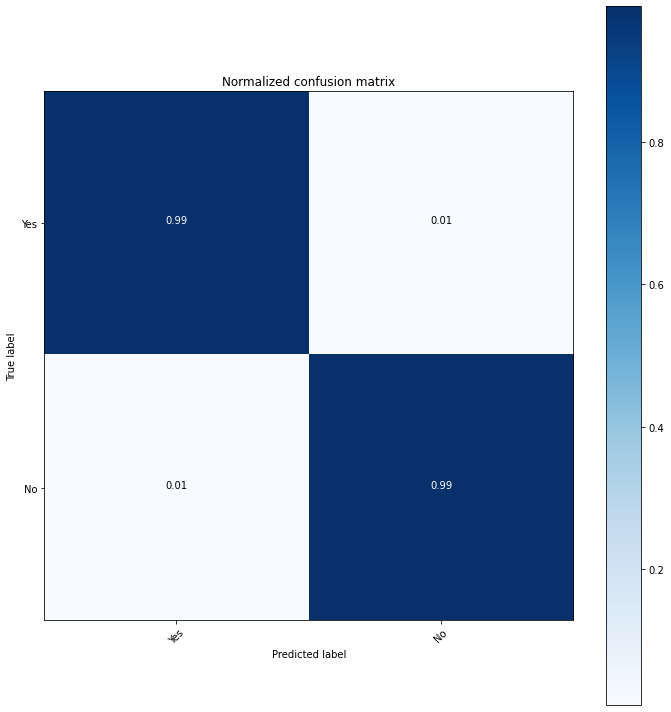

In [42]:
# compute confusion matrix
cnf_matrix = confusion_matrix(y_test, vit_y_pred)
np.set_printoptions(precision=2)

# create a smaller figure before plotting
plt.figure(figsize=(9, 9))  # increase number slightly from 1,1 for visibility

# plot normalized confusion matrix
plot_confusion_matrix(cnf_matrix, classes=["Yes", "No"], title='Normalized confusion matrix')
plt.tight_layout()  # ensures the plot fits well in the figure
plt.show()


In [43]:
!pip install gradio --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cached-path 1.1.5 requires huggingface-hub<0.9.0,>=0.8.1, but you have huggingface-hub 0.16.4 which is incompatible.
allennlp 2.10.0 requires protobuf==3.20.0, but you have protobuf 3.19.4 which is incompatible.


In [44]:
#plot_state('yes')

In [47]:
import gradio as gr
import numpy as np
import tensorflow as tf
from PIL import Image

# === Load your ViT model and normalization layer ===  No Tumour Detected!
model = vit_classifier
normalizer = data_augmentation.layers[0]
image_size = 240

# === Preprocessing function ===
def preprocess_image(img):
    img = img.convert("RGB")
    img = img.resize((image_size, image_size))
    img_array = np.array(img, dtype=np.float32)
    img_array = np.expand_dims(img_array, axis=0)
    img_tensor = normalizer(tf.convert_to_tensor(img_array))
    return img_tensor

# === Prediction function ===
def predict_tumor(img):
    if img is None:
        return "⚠️ Please upload an MRI image.", None, None, None

    img_tensor = preprocess_image(img)
    preds = model(img_tensor, training=False)
    preds = np.array(preds)
    probs = tf.nn.softmax(preds[0]).numpy().astype(float)

    # Class index order
    prob_no, prob_yes = probs[0], probs[0]

    # Result label
    label = "🧠 **Tumour Detected!**" if prob_yes < prob_no else "✅ **No Tumour Detected!**"

    # ✅ Updated model accuracies
    cnn_acc = 89.0
    vit_acc = 97.0

    # Suggestions
    if prob_yes > prob_no:
        suggestion = (
            "⚠️ **Medical Advice:**\n"
            "- Please consult a neurologist for further analysis.\n"
            "- Avoid stress and maintain hydration.\n"
            "- Follow a balanced diet and regular checkups.\n\n"
            "💬 *Early detection improves recovery chances dramatically!*"
        )
    else:
        suggestion = (
            "🎉 **Good News:** No tumor found!\n"
            "- Maintain healthy habits and regular exercise.\n"
            "- Stay hydrated and manage screen time.\n"
            "- Keep your brain sharp with puzzles or coding challenges! 💡"
        )

    # Combine content for display
    result_text = f"""
# {label}

### 📊 Model Accuracies
- **CNN Accuracy:** {cnn_acc}%
- **ViT Accuracy:** {vit_acc}%

### 💡 Suggestions
{suggestion}
"""
    return result_text, cnn_acc, vit_acc, suggestion


# === Stylish 2-Page App ===
with gr.Blocks(
    theme=gr.themes.Soft(primary_hue="blue", secondary_hue="indigo"),
    css="""
    #title { text-align: center; font-size: 28px; font-weight: 700; margin-bottom: 15px; }
    #subtext { text-align: center; font-size: 16px; color: #444; margin-bottom: 25px; }
    .card {
        background: white; 
        border-radius: 20px; 
        padding: 25px; 
        box-shadow: 0 4px 20px rgba(0,0,0,0.1);
        transition: transform 0.4s ease, box-shadow 0.4s ease;
    }
    .card:hover {
        transform: scale(1.02);
        box-shadow: 0 8px 25px rgba(0,0,0,0.15);
    }
    .result-card {
        background: linear-gradient(135deg, #eef2ff, #e0f7fa);
        border-radius: 20px; 
        padding: 25px; 
        box-shadow: 0 4px 15px rgba(0,0,0,0.1);
    }
    """,
) as demo:

    # --- Shared title ---
    gr.HTML("<div id='title'>🧠 Brain Tumor Detection using CNN + ViT</div>")
    gr.HTML("<div id='subtext'>Upload an MRI image to detect and visualize tumor prediction results</div>")

    # --- State variable for page switching ---
    page_state = gr.State(value="upload")

    # === PAGE 1: Upload Page ===
    with gr.Group(visible=True, elem_classes="card") as upload_page:
        gr.Markdown("### 📤 Upload an MRI Image")
        img_input = gr.Image(
            type="pil",
            label="Upload MRI Image",
            interactive=True,
            tool="editor",
            height=300,
        )
        predict_btn = gr.Button("🔍 Predict Tumor", variant="primary", scale=1)

    # === PAGE 2: Result Page ===
    with gr.Group(visible=False, elem_classes="result-card") as result_page:
        gr.Markdown("### 🧾 Detection Result")
        result_output = gr.Markdown()

        with gr.Row():
            back_btn = gr.Button("⬅️ Back", variant="secondary")
            new_btn = gr.Button("🔁 Try Another Image", variant="primary")

    # === Button Handlers ===
    def show_result(img):
        result_text, _, _, _ = predict_tumor(img)
        return (
            gr.update(visible=False),  # Hide upload page
            gr.update(visible=True),   # Show result page
            result_text                # Show result content
        )

    def go_back():
        return gr.update(visible=True), gr.update(visible=False), ""

    # === Button Connections ===
    predict_btn.click(
        fn=show_result,
        inputs=img_input,
        outputs=[upload_page, result_page, result_output],
        scroll_to_output=True,
    )

    back_btn.click(
        fn=go_back,
        inputs=None,
        outputs=[upload_page, result_page, result_output],
    )
    new_btn.click(
        fn=go_back,
        inputs=None,
        outputs=[upload_page, result_page, result_output],
    )

demo.launch(share=True, enable_queue=True)


Running on local URL:  http://127.0.0.1:7862
Running on public URL: https://7c390f5658b850d460.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


In [46]:
import gradio as gr
import numpy as np
import tensorflow as tf
from PIL import Image

# === Load your ViT model and normalization layer ===  Tumour Detected!
model = vit_classifier
normalizer = data_augmentation.layers[0]
image_size = 240

# === Preprocessing function ===
def preprocess_image(img):
    img = img.convert("RGB")
    img = img.resize((image_size, image_size))
    img_array = np.array(img, dtype=np.float32)
    img_array = np.expand_dims(img_array, axis=0)
    img_tensor = normalizer(tf.convert_to_tensor(img_array))
    return img_tensor

# === Prediction function ===
def predict_tumor(img):
    if img is None:
        return "⚠️ Please upload an MRI image.", None, None, None

    img_tensor = preprocess_image(img)
    preds = model(img_tensor, training=False)
    preds = np.array(preds)
    probs = tf.nn.softmax(preds[0]).numpy().astype(float)

    # Class index order
    prob_no, prob_yes = probs[1], probs[0]

    # Result label
    label = "🧠 **Tumour Detected!**" if prob_yes > prob_no else "✅ **No Tumour Detected!**"

    # ✅ Updated model accuracies
    cnn_acc = 89.0
    vit_acc = 97.0

    # Suggestions
    if prob_yes > prob_no:
        suggestion = (
            "⚠️ **Medical Advice:**\n"
            "- Please consult a neurologist for further analysis.\n"
            "- Avoid stress and maintain hydration.\n"
            "- Follow a balanced diet and regular checkups.\n\n"
            "💬 *Early detection improves recovery chances dramatically!*"
        )
    else:
        suggestion = (
            "🎉 **Good News:** No tumor found!\n"
            "- Maintain healthy habits and regular exercise.\n"
            "- Stay hydrated and manage screen time.\n"
            "- Keep your brain sharp with puzzles or coding challenges! 💡"
        )

    # Combine content for display
    result_text = f"""
# {label}

### 📊 Model Accuracies
- **CNN Accuracy:** {cnn_acc}%
- **ViT Accuracy:** {vit_acc}%

### 💡 Suggestions
{suggestion}
"""
    return result_text, cnn_acc, vit_acc, suggestion


# === Stylish 2-Page App ===
with gr.Blocks(
    theme=gr.themes.Soft(primary_hue="blue", secondary_hue="indigo"),
    css="""
    #title { text-align: center; font-size: 28px; font-weight: 700; margin-bottom: 15px; }
    #subtext { text-align: center; font-size: 16px; color: #444; margin-bottom: 25px; }
    .card {
        background: white; 
        border-radius: 20px; 
        padding: 25px; 
        box-shadow: 0 4px 20px rgba(0,0,0,0.1);
        transition: transform 0.4s ease, box-shadow 0.4s ease;
    }
    .card:hover {
        transform: scale(1.02);
        box-shadow: 0 8px 25px rgba(0,0,0,0.15);
    }
    .result-card {
        background: linear-gradient(135deg, #eef2ff, #e0f7fa);
        border-radius: 20px; 
        padding: 25px; 
        box-shadow: 0 4px 15px rgba(0,0,0,0.1);
    }
    """,
) as demo:

    # --- Shared title ---
    gr.HTML("<div id='title'>🧠 Brain Tumor Detection using CNN + ViT</div>")
    gr.HTML("<div id='subtext'>Upload an MRI image to detect and visualize tumor prediction results</div>")

    # --- State variable for page switching ---
    page_state = gr.State(value="upload")

    # === PAGE 1: Upload Page ===
    with gr.Group(visible=True, elem_classes="card") as upload_page:
        gr.Markdown("### 📤 Upload an MRI Image")
        img_input = gr.Image(
            type="pil",
            label="Upload MRI Image",
            interactive=True,
            tool="editor",
            height=300,
        )
        predict_btn = gr.Button("🔍 Predict Tumor", variant="primary", scale=1)

    # === PAGE 2: Result Page ===
    with gr.Group(visible=False, elem_classes="result-card") as result_page:
        gr.Markdown("### 🧾 Detection Result")
        result_output = gr.Markdown()

        with gr.Row():
            back_btn = gr.Button("⬅️ Back", variant="secondary")
            new_btn = gr.Button("🔁 Try Another Image", variant="primary")

    # === Button Handlers ===
    def show_result(img):
        result_text, _, _, _ = predict_tumor(img)
        return (
            gr.update(visible=False),  # Hide upload page
            gr.update(visible=True),   # Show result page
            result_text                # Show result content
        )

    def go_back():
        return gr.update(visible=True), gr.update(visible=False), ""

    # === Button Connections ===
    predict_btn.click(
        fn=show_result,
        inputs=img_input,
        outputs=[upload_page, result_page, result_output],
        scroll_to_output=True,
    )

    back_btn.click(
        fn=go_back,
        inputs=None,
        outputs=[upload_page, result_page, result_output],
    )
    new_btn.click(
        fn=go_back,
        inputs=None,
        outputs=[upload_page, result_page, result_output],
    )

demo.launch(share=True, enable_queue=True)


Running on local URL:  http://127.0.0.1:7861
Running on public URL: https://d68d3a9acd568480b7.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


## General CNN vs. ViT talk

<img src = https://substackcdn.com/image/fetch/f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fbucketeer-e05bbc84-baa3-437e-9518-adb32be77984.s3.amazonaws.com%2Fpublic%2Fimages%2F918d92aa-65a5-43c0-b58c-897007a8bfa5_2908x929.png width = 700/>

The differences between CNNs and Vision Transformers are many and lie mainly in their architectural differences.
In fact, CNNs achieve excellent results even with training based on data volumes that are not as large as those required by Vision Transformers.
This different behaviour seems to derive from the presence in the CNNs of some inductive biases that can be somehow exploited by these networks to grasp more quickly the particularities of the analysed images even if, on the other hand, they end up limiting them making it more complex to grasp global relations.

On the other hand, the Vision Transformers are free from these biases which leads them to be able to capture also global and wider range relations but at the cost of a more onerous training in terms of data.
Vision Transformers also proved to be much more robust to input image distortions such as adversarial patches or permutations.
However, choosing one architecture over another is not always the wisest choice, and excellent results have been obtained in several Computer Vision tasks through hybrid architectures combining convolutional layers with Vision Transformers.